In [ ]:
pip install -U sentence-transformers faiss-cpu transformers python-docx


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 103.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 26.2 MB/s eta 0:00:00


In [ ]:
import faiss
import numpy as np


In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "BAAI/bge-m3",
    trust_remote_code=True
)


In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("BAAI/bge-m3")


In [ ]:
import re

def split_parents(raw_text):
    lines = raw_text.splitlines()
    parents = []
    current = []

    heading_pattern = re.compile(r"^\s*\d+\.\s+")

    for line in lines:
        if heading_pattern.match(line):
            if current:
                parents.append("\n".join(current).strip())
                current = []
        current.append(line)

    if current:
        parents.append("\n".join(current).strip())

    return parents


In [ ]:
def chunk_children(parent_text, max_words=1000):
    lines = [l for l in parent_text.splitlines() if l.strip()]
    chunks = []
    current = []

    for line in lines:
        if len((" ".join(current + [line])).split()) <= max_words:
            current.append(line)
        else:
            chunks.append("\n".join(current))
            current = [line]

    if current:
        chunks.append("\n".join(current))

    return chunks


In [ ]:
def build_parent_child_chunks(raw_text):
    parents = split_parents(raw_text)
    records = []

    for pid, parent_text in enumerate(parents):
        children = chunk_children(parent_text, max_words=1000)

        for cid, child in enumerate(children):
            records.append({
                "parent_id": pid,
                "child_id": cid,
                "parent_title": parent_text.splitlines()[0],
                "child_text": child
            })

    return records


In [ ]:
def embed_passages(texts):
    texts = ["passage: " + t for t in texts]
    return model.encode(
        texts,
        normalize_embeddings=True,
        batch_size=16
    )


In [ ]:
def embed_query(query):
    return model.encode(
        "query: " + query,
        normalize_embeddings=True
    )


In [ ]:
def build_faiss(vectors):
    dim = vectors.shape[1]
    index = faiss.IndexFlatIP(dim)
    index.add(vectors)
    return index


In [ ]:
from docx import Document

def read_docx(path):
    doc = Document(path)
    lines = []

    for para in doc.paragraphs:
        text = para.text.strip()
        if text:
            lines.append(text)

    return "\n\n".join(lines)


In [ ]:
# 1. Đọc nội dung từ cả 2 file
print("Đang đọc file data1.docx...")
text1 = read_docx("data1.docx")

print("Đang đọc file data2.docx...")
text2 = read_docx("data2.docx")

Đang đọc file data1.docx...
Đang đọc file data2.docx...


In [ ]:
# 2. Phân chia thành các đoạn (chunks) cho từng file
print("Đang xử lý phân đoạn...")
records1 = build_parent_child_chunks(text1)
records2 = build_parent_child_chunks(text2)

# 3. GỘP DỮ LIỆU: Nối 2 danh sách lại với nhau
records = records1 + records2

print(f"✅ Đã nạp thành công! Tổng cộng có {len(records)} đoạn văn bản từ cả 2 file.")

# 4. Tạo Vector và Index lại từ đầu cho dữ liệu gộp
print("Đang tạo Vector (Embedding)... (Bước này có thể hơi lâu)")
child_texts = [r["child_text"] for r in records]
child_embeddings = embed_passages(child_texts)
index = build_faiss(child_embeddings)

print("✅ Đã xây dựng xong hệ thống tìm kiếm cho cả 2 file!")





Đang xử lý phân đoạn...
✅ Đã nạp thành công! Tổng cộng có 537 đoạn văn bản từ cả 2 file.
Đang tạo Vector (Embedding)... (Bước này có thể hơi lâu)
✅ Đã xây dựng xong hệ thống tìm kiếm cho cả 2 file!


In [ ]:
print(records)

[{'parent_id': 0, 'child_id': 0, 'parent_title': '1. Trẻ biếng ăn', 'child_text': '1. Trẻ biếng ăn\nĐa phần trẻ biếng ăn là do tâm lý và do những sai lầm\ncủa cha mẹ trong cách chế biến thức ăn và thời gian\nchuyển tiếp chế độ ăn cho trẻ. Vì vậy, những bậc cha mẹ\nnên thực hiện theo những cách sau để kích thích cho trẻ ăn\ntốt hơn:\n- Không nên ép buộc trẻ, đánh lừa trẻ khi cho trẻ ăn sẽ\ntạo nên tâm lý chán ăn cho trẻ.\n- Nên tạo ra không khí vui vẻ, thoải mái khi trẻ ăn và\nkhông nên cho trẻ ăn ở nơi đông người.\n- Cho trẻ tự lựa chọn thức ăn, hãy để trẻ tiếp nhận các\nmón ăn như một món đồ chơi mà chúng yêu thích.\n- Không nên cho thuốc vào thức ăn hay vào sữa của trẻ.\n- Không nên pha bột vào sữa, pha sữa quá đặc, pha sữa\nbằng nước cháo, nước hầm xương... làm trẻ khó tiêu.\n- Không nên pha bột quá đặc khi trẻ mới tập ăn dặm.\n- Thường xuyên đổi món nhưng phải đảm bảo đây đủ\nchất dinh dưỡng cho khẩu phần ăn cho trẻ.\n- Chỉ cho trẻ ăn nước rau, nước thịt, không ăn bã. Nên\ncẩn thận

In [ ]:
def retrieve_parents(query, top_k=5):
    q_vec = embed_query(query)

    scores, indices = index.search(
        np.array([q_vec]),
        top_k
    )

    parent_map = {}
    for idx in indices[0]:
        record = records[idx]
        pid = record["parent_id"]
        parent_map[pid] = record["child_text"]

    return list(parent_map.values())


In [ ]:
query = "trẻ con bị đau răng"

parents = retrieve_parents(query,top_k=5)

for i, p in enumerate(parents):
    print(f"\n--- PARENT {i} ---")
    print(p[:10000])



--- PARENT 0 ---
3. Trẻ bị sâu răng
Nên cho trẻ chải răng thường xuyên vào buổi sáng
hoặc tối, chải răng đúng cách bằng bàn chải lông mềm.
Sau đó súc miệng lần cuối bằng nước chè tươi, chè hạt
hoặc nước vối (vì chè có nhiều flo).
Nếu trẻ bị sâu răng cần điều trị sớm bằng khoan răng
và trầm răng. Cần phải điều trị sớm, không nên đợi khi
răng đau mới chữa.

--- PARENT 1 ---
2. Trẻ chậm mọc răng
Trẻ đến tuổi mà chưa mọc răng. Bắt một con chuột đực
sống, rồi mổ bụng, lấy xương sống chuột đốt tổn tính rồi
tán nhỏ xát lên nướu là răng sẽ mọc.

--- PARENT 2 ---
1. Trẻ bị nhọt lưỡi
Trẻ bú không được. Lấy phèn chua trộn với trứng gà,
với giấm, đắp lên gan bàn chân trẻ.

--- PARENT 3 ---
59. Nhức răng
Cách 1: Vỏ dưa hấu phơi qua đêm, đốt ra tro cho đắp
vào chỗ nhức và kẽ răng.
Cách 2: Tán nhỏ 1 đồng cân mai có mực bỏ vào giấm.
Người đau nằm nghiêng trên giường, lấy muỗng canh múc
phân nửa muỗng thuốc đó vào lỗ tai trái, chừng 3 phút sau
nghiêng tai cho nước thuốc chảy ra. Theo cách ấy, đổ
thuốc

In [ ]:
# Cài đặt thư viện để chạy LLM (bitsandbytes giúp giảm dung lượng model xuống 4-bit)
!pip install -q -U bitsandbytes accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 13.7 MB/s eta 0:00:00


In [ ]:
# Cài đặt lại bitsandbytes và accelerate phiên bản mới nhất
!pip install -q -U bitsandbytes accelerate transformers

In [ ]:
!pip install sentence-transformers

In [ ]:
# Cài đặt thư viện để chạy LLM (bitsandbytes giúp giảm dung lượng model xuống 4-bit)
!pip install -q -U bitsandbytes accelerate

In [ ]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

# ==========================================
# PHẦN 1: TẢI MODEL GENERATIVE (QWEN)
# ==========================================

# Cấu hình lượng tử hóa (giảm nhẹ model xuống 4-bit để chạy trên Colab T4)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

model_id = "Qwen/Qwen2.5-7B-Instruct"

print("⏳ Đang tải Model Gen (LLM)... Vui lòng đợi khoảng 2-3 phút.")
try:
    tokenizer_gen = AutoTokenizer.from_pretrained(model_id)
    model_gen = AutoModelForCausalLM.from_pretrained(
        model_id,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True
    )
    print("✅ Đã tải xong Model!")
except Exception as e:
    print(f"❌ Lỗi khi tải model: {e}")

⏳ Đang tải Model Gen (LLM)... Vui lòng đợi khoảng 2-3 phút.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

✅ Đã tải xong Model!


In [ ]:
# ==========================================
# PHẦN 3: HÀM TÌM KIẾM CÓ KIỂM TRA (RETRIEVAL WITH CHECK)
# ==========================================

from sentence_transformers import CrossEncoder
import numpy as np

# 1. Tải Model Reranker (Chạy 1 lần, model này nhẹ nhưng rất thông minh)
print("⏳ Đang tải model Re-ranker (Chấm điểm lại)...")
reranker = CrossEncoder('BAAI/bge-reranker-v2-m3')
# Hoặc dùng 'BAAI/bge-reranker-base' nếu muốn nhẹ hơn nữa
print("✅ Đã tải xong Re-ranker!")

# 2. Hàm tìm kiếm nâng cấp (Vector Search + Reranking)
def retrieve_parents_with_check(query, top_k=1, threshold=0.45): # threshold này áp dụng cho vector
    # BƯỚC 1: TÌM KIẾM THÔ (Vector Search) - Lấy nhiều kết quả hơn (ví dụ top 10) để lọc
    initial_top_k = 10
    q_vec = embed_query(query)

    # Tìm 10 ứng viên tiềm năng nhất
    scores, indices = index.search(np.array([q_vec]), initial_top_k)

    current_scores = scores[0]
    current_indices = indices[0]

    # Lọc sơ bộ bằng vector threshold (0.45)
    candidates = []
    for score, idx in zip(current_scores, current_indices):
        if score >= threshold:
            candidates.append(records[idx]["child_text"])

    if not candidates:
        return None

    # BƯỚC 2: CHẤM ĐIỂM LẠI (RE-RANKING) - Bước quan trọng nhất
    # Tạo các cặp [Câu hỏi, Đoạn văn] để model đọc hiểu ngữ cảnh
    pairs = [[query, doc] for doc in candidates]

    # Model Cross-Encoder chấm điểm (Score này có thể âm hoặc dương, càng cao càng tốt)
    rerank_scores = reranker.predict(pairs)

    # BƯỚC 3: SẮP XẾP LẠI THEO ĐIỂM MỚI
    # Kết hợp văn bản và điểm số mới
    ranked_results = sorted(zip(candidates, rerank_scores), key=lambda x: x[1], reverse=True)

    # BƯỚC 4: LẤY TOP_K TỐT NHẤT VÀ KIỂM TRA NGƯỠNG RERANK
    # Reranker score của BGE thường > 0 là liên quan, < 0 là không liên quan lắm
    # Bạn có thể đặt rerank_threshold = -2 hoặc 0 tùy độ khắt khe
    rerank_threshold = -4.0

    final_results = []
    print("\n🔍 CHI TIẾT ĐIỂM SỐ (RERANKING):")
    for doc, score in ranked_results[:top_k]:
        print(f"   - Score: {score:.4f} | Nội dung đầu: {doc[:50]}...")
        if score > rerank_threshold:
            final_results.append(doc)

    return final_results if final_results else None


⏳ Đang tải model Re-ranker (Chấm điểm lại)...
✅ Đã tải xong Re-ranker!


In [ ]:
def generate_conversational_answer(query, context_list):
    """
    Hàm này dùng Model AI để tạo ra câu trả lời tự nhiên.
    Phiên bản FIX LỖI: Xử lý cắt chuỗi an toàn để không bị mất chữ.
    """
    context_str = "\n".join([f"- Đoạn {i+1}: {ctx}" for i, ctx in enumerate(context_list)])

    system_prompt = """Bạn là một Bác sĩ tư vấn y học cổ truyền tận tâm và thân thiện.

    NHIỆM VỤ:
    1. Đọc kỹ các đoạn tài liệu tham khảo được cung cấp.
    2. Trả lời câu hỏi của người dùng dựa trên các tài liệu đó.
    3. Nếu tài liệu có nhắc đến cách chữa, hãy hướng dẫn chi tiết cho người dùng.
    4. Nếu tài liệu không khớp hoàn toàn (ví dụ người dùng hỏi 'ê răng' mà tài liệu chỉ có 'đau răng'), hãy khéo léo gợi ý các cách chữa gần nhất.
    5. Tuyệt đối không bịa đặt.
    """

    user_prompt = f"""
    ### TÀI LIỆU THAM KHẢO TỪ HỆ THỐNG:
    {context_str}

    ### CÂU HỎI CỦA BỆNH NHÂN:
    {query}

    ### TRẢ LỜI:
    (Hãy trả lời ân cần, chi tiết như một bác sĩ đang nói chuyện với bệnh nhân)
    """

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]

    text = tokenizer_gen.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer_gen([text], return_tensors="pt").to(model_gen.device)

    with torch.no_grad():
        generated_ids = model_gen.generate(
            input_ids=inputs.input_ids,
            attention_mask=inputs.attention_mask,
            pad_token_id=tokenizer_gen.eos_token_id,
            max_new_tokens=1024,
            temperature=0.3,
            do_sample=True,
            repetition_penalty=1.05
        )

    input_length = inputs.input_ids.shape[1]

    generated_tokens = generated_ids[0][input_length:]

    response = tokenizer_gen.decode(generated_tokens, skip_special_tokens=True)

    if not response.strip():
        return "Xin lỗi, tôi đang gặp trục trặc khi suy nghĩ câu trả lời. Vui lòng xem phần trích dẫn bên dưới."

    return response


In [ ]:
import os
import re
from docx import Document
from IPython.display import display, Image, HTML

# ==============================================================================
# BIẾN TOÀN CỤC
# ==============================================================================
IMAGE_MAPPING = {}

# ==============================================================================
# HÀM 1: TỰ ĐỘNG QUÉT VÀ GHÉP ẢNH (HỖ TRỢ TÊN FILE .DOCX.PNG)
# ==============================================================================
def map_images_multi_source(docx_files_list):
    global IMAGE_MAPPING
    IMAGE_MAPPING = {}

    print(f"🚀 Bắt đầu quy trình ghép ảnh cho {len(docx_files_list)} file tài liệu...\n")

    for docx_path in docx_files_list:
        base_name = os.path.splitext(docx_path)[0]
        image_folder = base_name

        print(f"🔹 Đang xử lý: {docx_path} (Tìm ảnh trong thư mục '{image_folder}/')...")

        if not os.path.exists(docx_path):
            print(f"   ⚠️ Lỗi: Không tìm thấy file Word '{docx_path}'.")
            continue

        local_images = {}
        if os.path.exists(image_folder):
            valid_ext = ('.png', '.jpg', '.jpeg', '.bmp', '.gif')
            for f in os.listdir(image_folder):
                if f.lower().endswith(valid_ext):
                    # --- SỬA ĐỔI TẠI ĐÂY ---
                    # 1. Bỏ đuôi ảnh (ví dụ: data2-pic1.docx.png -> data2-pic1.docx)
                    name_clean = os.path.splitext(f)[0]

                    # 2. Bỏ tiếp đuôi .docx nếu có (data2-pic1.docx -> data2-pic1)
                    if name_clean.lower().endswith('.docx'):
                        name_clean = os.path.splitext(name_clean)[0]

                    # Lưu vào danh sách (Key đã sạch: "data2-pic1")
                    local_images[name_clean] = f

            print(f"   -> Tìm thấy {len(local_images)} file ảnh trong thư mục '{image_folder}'.")

        # Quét file Word để khớp ảnh
        try:
            doc = Document(docx_path)
            mapped_count = 0

            for para in doc.paragraphs:
                matches = re.findall(r'<(.*?)>', para.text)

                for tag_content in matches:
                    original_tag = f"<{tag_content}>"

                    # Làm sạch tên trong thẻ (ví dụ thẻ <data2-pic1.png>)
                    tag_name_clean = os.path.splitext(tag_content)[0]
                    # Nếu thẻ cũng bị dính docx (ít gặp, nhưng cứ xử lý cho chắc)
                    if tag_name_clean.lower().endswith('.docx'):
                        tag_name_clean = os.path.splitext(tag_name_clean)[0]

                    # SO KHỚP: data2-pic1 (từ thẻ) == data2-pic1 (từ file data2-pic1.docx.png)
                    if tag_name_clean in local_images:
                        real_file_name = local_images[tag_name_clean]
                        full_path = os.path.join(image_folder, real_file_name)

                        IMAGE_MAPPING[original_tag] = full_path
                        mapped_count += 1

            print(f"   ✅ Đã ghép được {mapped_count} ảnh từ file {docx_path}.")

        except Exception as e:
            print(f"   ❌ Lỗi khi đọc file {docx_path}: {e}")

        print("-" * 40)

    print(f"\n🎉 HOÀN TẤT! Tổng cộng hệ thống đã ghi nhớ {len(IMAGE_MAPPING)} cặp ảnh.")

# ==============================================================================
# HÀM HIỂN THỊ (GIỮ NGUYÊN)
# ==============================================================================
def display_result_with_images(text_chunk):
    pattern = r'(<.*?>)'
    parts = re.split(pattern, text_chunk)
    for part in parts:
        part = part.strip()
        if not part: continue
        if part in IMAGE_MAPPING and os.path.exists(IMAGE_MAPPING[part]):
            display(Image(filename=IMAGE_MAPPING[part], width=400))
            print(f"(Ảnh minh họa: {os.path.basename(IMAGE_MAPPING[part])})")
        elif re.match(r'<.*\.(?:png|jpg|jpeg)>', part):
             pass
        else:
            print(part)

# ==============================================================================
# HÀM 3: CHATBOT (CẬP NHẬT GỌI HÀM HIỂN THỊ)
# ==============================================================================
def chatbot_final_mixed(user_query):
    # (Phần tìm kiếm và AI giữ nguyên như các bước trước)
    # Đây là bản rút gọn để demo phần hiển thị ảnh
    print(f"\nUser hỏi: {user_query}")
    print("-" * 60)

    # Giả sử hàm tìm kiếm đã chạy và trả về contexts
    try:
        contexts = retrieve_parents_with_check(user_query, top_k=1, threshold=0.45)
    except:
        print("⚠️ (Chưa chạy hàm tìm kiếm, đây là demo hiển thị ảnh)")
        return

    if contexts:
        # ... Phần AI trả lời ...

        print("="*40)
        print("📄 **BẰNG CHỨNG TỪ TÀI LIỆU GỐC:**")
        for ctx in contexts:
            print(f"\n--- [Nguồn trích dẫn] ---\n")
            display_result_with_images(ctx)
        print("\n" + "="*40)
    else:
        print("Không tìm thấy thông tin.")

# ==============================================================================
# CHẠY CẤU HÌNH
# ==============================================================================

# 1. Khai báo danh sách các file Word bạn muốn hệ thống học
# Lưu ý: Bạn cần có thư mục "data1" và "data2" tương ứng nằm cạnh file notebook
list_files = ["data1.docx", "data2.docx"]

# 2. Chạy hàm quét tự động
map_images_multi_source(list_files)

🚀 Bắt đầu quy trình ghép ảnh cho 2 file tài liệu...

🔹 Đang xử lý: data1.docx (Tìm ảnh trong thư mục 'data1/')...
   ✅ Đã ghép được 0 ảnh từ file data1.docx.
----------------------------------------
🔹 Đang xử lý: data2.docx (Tìm ảnh trong thư mục 'data2/')...
   -> Tìm thấy 31 file ảnh trong thư mục 'data2'.
   ✅ Đã ghép được 31 ảnh từ file data2.docx.
----------------------------------------

🎉 HOÀN TẤT! Tổng cộng hệ thống đã ghi nhớ 31 cặp ảnh.


In [ ]:
# ==============================================================================
# HÀM CHATBOT TỔNG HỢP: MIXED + ẢNH + 1 KẾT QUẢ DUY NHẤT
# ==============================================================================

def chatbot_final_mixed(user_query, mode="mixed"):
    """
    Hàm Chatbot hoàn chỉnh nhất.
    - user_query: Câu hỏi người dùng.
    - mode: "mixed" (Mặc định) - Hiện cả Chat và Bằng chứng gốc kèm ảnh.
    """
    print(f"\nUser hỏi: {user_query}")
    print("-" * 60)

    # 1. TÌM KIẾM (CHỈ LẤY 1 KẾT QUẢ DUY NHẤT)
    # top_k=1: Chỉ lấy đoạn văn sát nhất với câu hỏi
    try:
        contexts = retrieve_parents_with_check(user_query, top_k=3, threshold=0.55)
    except NameError:
        print("❌ Lỗi: Hàm tìm kiếm chưa được định nghĩa. Hãy chạy lại các cell bên trên.")
        return

    if contexts is None:
        print("🤖 Bot: Xin lỗi, không tìm thấy thông tin phù hợp trong tài liệu.")
        return

    # 2. PHẦN 1: CHATBOT TRẢ LỜI (AI SUY LUẬN)
    # (Chỉ chạy nếu mode là 'mixed' hoặc 'chat')
    if mode in ["chat", "mixed"]:
        print("-> Đang suy nghĩ câu trả lời...")

        # Gọi hàm sinh câu trả lời (Hàm bạn đã fix lỗi cắt chữ ở bước trước)
        ai_answer = generate_conversational_answer(user_query, contexts)

        print(f"\n🤖 **CHATBOT TRẢ LỜI:**")
        print(f"{ai_answer}\n")

    # 3. PHẦN 2: TRÍCH DẪN NGUYÊN VĂN KÈM ẢNH (EVIDENCE)
    # (Chỉ chạy nếu mode là 'mixed' hoặc 'exact')
    if mode in ["exact", "mixed"]:
        print("="*40)
        print("📄 **BẰNG CHỨNG TỪ TÀI LIỆU GỐC (KÈM ẢNH):**")

        # Duyệt qua kết quả (lúc này chỉ có 1 kết quả)
        for i, ctx in enumerate(contexts):
            print(f"\n--- [Nguồn trích dẫn tốt nhất] ---\n")

            # Gọi hàm hiển thị thông minh (Tự động tách văn bản và load ảnh)
            # Hàm này bạn đã định nghĩa ở cell trước
            display_result_with_images(ctx)

        print("\n" + "="*40)

# ==============================================================================
# CHẠY THỬ NGHIỆM
# ==============================================================================

# 1. Đảm bảo bạn đã map ảnh (Chạy 1 lần nếu chưa chạy)
# map_images_by_order(DOCX_PATH, IMAGE_FOLDER)

# 2. Gọi Chatbot
# Ví dụ: Hỏi về bệnh lở miệng (trong data1) hoặc cây thuốc (trong data2)
print("Sẵn sàng! Hãy thử đặt câu hỏi.")
# chatbot_final_mixed("Tôi thèm ăn nóng nhưng bị lở miệng có cách chữa không?")

Sẵn sàng! Hãy thử đặt câu hỏi.



User hỏi: Cây tía tô dùng làm gì?
------------------------------------------------------------

🔍 CHI TIẾT ĐIỂM SỐ (RERANKING):
   - Score: 0.8831 | Nội dung đầu: 29. THỔ CAO LY SÂM
Tên khác: Giả nhân sâm - Thổ nh...
   - Score: 0.5979 | Nội dung đầu: 8. GAI
"Tên khác: Cây gai - Trữ ma-Gal tuyết.Cây b...
   - Score: 0.2410 | Nội dung đầu: 1. BẠC HÀ
Tên khác: Kê tô - Thuỷ tô - Cha Phiác ho...
-> Đang suy nghĩ câu trả lời...

🤖 **CHATBOT TRẢ LỜI:**
Chào bạn! Cây tía tô có nhiều tác dụng tốt cho sức khỏe, đặc biệt là trong việc điều trị và phòng ngừa một số bệnh lý thông thường. Dưới đây là một số công dụng chính của tía tô:

1. **Chữa cảm lạnh và cảm cúm**: Tía tô có tác dụng chống lại cảm lạnh và cảm cúm. Bạn có thể sử dụng tía tô tươi hoặc khô để nấu cháo hoặc canh, kết hợp với hành hoa, gừng tươi để tăng hiệu quả.

2. **Giúp phụ nữ tránh bị động thai**: Tía tô có thể giúp phụ nữ tránh bị động thai bằng cách sử dụng cây tía tô tươi hoặc khô (20g) sắc với 600ml nước, còn 200ml, sau đó 

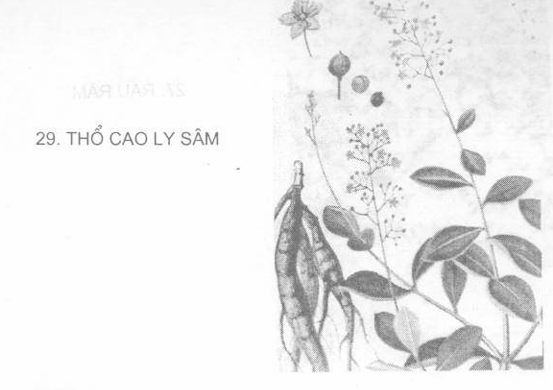

(Ảnh minh họa: data2-pic29.docx.png)
Bài 1,
An thân, chữa mất ngủ.
Lá thổ cao ly sâm 30-50g
Lá vông nem 30-50g
Rửa sạch nấu canh ăn, ngày ăn 2 lần.
Bài 2.
Bổ tỳ uị, kích thích tiêu hoá làm ăn ngon, an thân.
Củ thổ cao ly sâm 20g
Kỷ tử 10g
Long nhãn 12g
“Tất cả cho sắc với 300m] nước, còn 100ml, uống nóng
trước khi ăn cơm 1 giờ. Chia làm 2 lần uống trong ngày.
30 TÍA TÔ
Tên khác: Tử tô Mắng la (H mông) - Cùng pô (Đao)
Cách trồng: Gieo hạt vào mùa xuân, nơi đất tơi, xốp,
nhiều mùn, ẩm.
Bộ phận dùng: Lá, cành tươi hay khô và hạt.
Thu hái, chế biến: Hái lá bánh tẻ vào tháng 3-4,
phơi khô trong râm mát. Cây đã hái lá chặt cả cây lấy
cành phơi khô.
Hạt lấy ở cây không hái lá, khi quả già cắt cả cây phơi
trong râm mát đến khô, đập lấy hạt, lấy lá và cành.
Công dụng: Chữa cảm phong hàn, phụ nữ động thai,
ho suyễn, nhiều đờm, ngộ độc thức ăn.
Liều dùng: 5-20g/ngày.


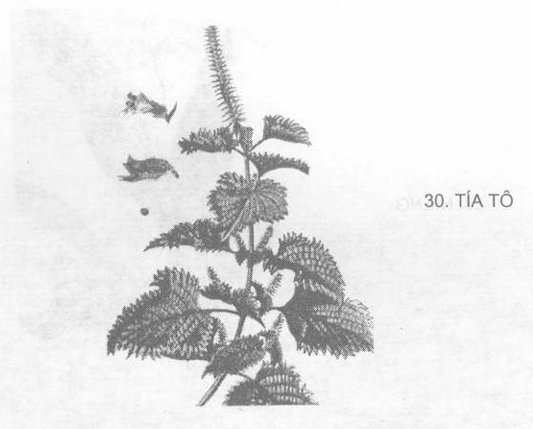

(Ảnh minh họa: data2-pic30.docx.png)
Bài 1.
Chữa cảm phong hàn.
Lá tía tô tươi 20g
Hành hoa tươi 10g
Gừng tươi 2
Tất cả rửa sạch, thái nhỏ trộn vào cháo nóng ăn xong
đắp chăn cho ra mồ hôi, ăn 2-3 ngày liền.
Bài 2.
Chữa phụ nữ động thai.
Cành tía tô (tô ngạnh) 20g
Củ gai 30g
Sắc với 600m1 nước, còn 200ml chia 3 lần uống trong
ngày, uống 1-2 ngày, có kết quả thì thôi.
Bài 3.
Chữa ho suyễn có đờm
(Xem bài 1 Cải củ trang 10).
Bài 4.
Chữa ngộ độc cua cá
Lá tía tô tươi 30g
Rửa sạch, giã vắt lấy nước uống hoặc lá tía tô khô 20g
sắc với 200m] nước đun sôi 10 phút uống nóng.

--- [Nguồn trích dẫn tốt nhất] ---

8. GAI
"Tên khác: Cây gai - Trữ ma-Gal tuyết.Cây bánh gai -
Co pán (Tày)
Cách trồng: Trồng bằng thân rễ vào mùa xuân.
Bộ phận dùng: TRễ và lá tươi hoặc khô.
Thu hái, chế biến: Hái lá bánh tẻ, dùng tươi hoặc
phơi khô trong râm mát. Đào rễ rửa sạch đất cát, thái
mồng (hoặc để nguyên, phơi khô).
Công dụng: Dùng chữa phụ nữ có thai ra huyết, đau
bụng, sa dạ con, trĩ, đái rắt, mụn nhọt.
Liều

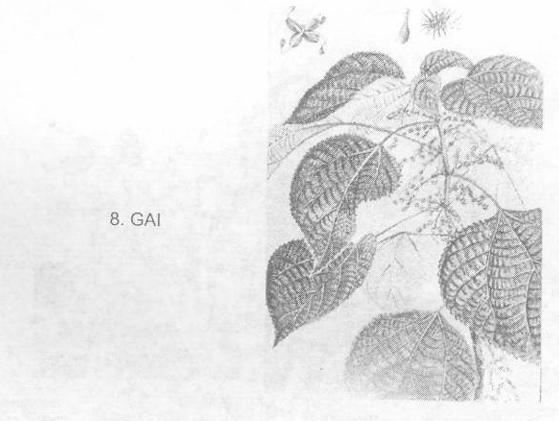

(Ảnh minh họa: data2-pic8.docx.png)
Bài 1.
Chữa phụ nữ có thai đau bụng, doa sẩy thai.
Củ gai (tươi hoặc khô) 30g
Cành tía tô (tươi hoặc khô) 90g
“Thêm 600 mì nước (3 bát ăn cơm) sắc còn 200 ml, chia
làm 3 lần uống trong ngày. Uống 1-2 ngày có kết quả thì
thôi, không nên uống kéo dài.
Bài 2.
Chữa sa dạ con, trí hậu môn.
Củ gai tươi hoặc khô 30g
'Thêm 600ml nước sắc còn 200ml chia 3 lần uống trong
ngày. Uống liền 5-6 ngày, cần chú ý theo dõi diễn biến của
bệnh.
Bài 3.
Chữa đái rối, tiểu tiện đục, uàng, đỏ.
Củ gai tươi hoặc khô (có thể dùng lá khô) 20-30g.
Sắc uống trong ngày.

--- [Nguồn trích dẫn tốt nhất] ---

1. BẠC HÀ
Tên khác: Kê tô - Thuỷ tô - Cha Phiác hom (Tày).
Bạc hà nam - Bạc hà cay - nhân đảm thảo.
Cách trồng: Trồng bằng đoạn thân bánh tẻ, mỗi
đoạn 10 em vào tháng 3-3 (mùa xuân), hoặc tháng 8-9
(mùa thu). Ưa đất nhiều bùn.
Bộ phận dùng: Toàn thân cây tươi hay khô.
"Thu hái, chế biến: Thu hái quanh năm, cắt bó từng
bó nhỏ, phơi nơi râm mát đến khô.
Công dụng: Chữa cảm sốt, ng

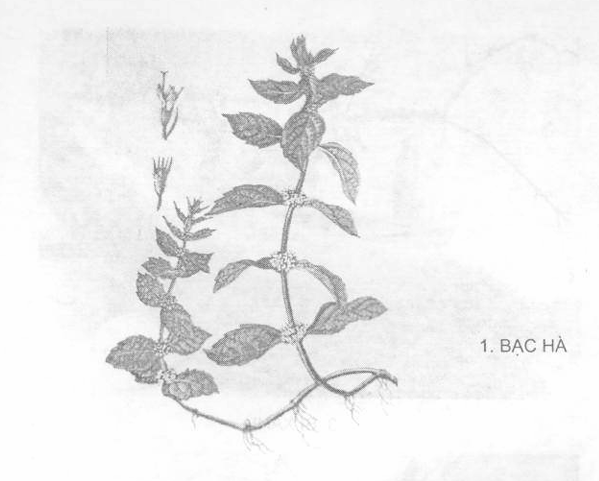

(Ảnh minh họa: data2-pic1.docx.png)
Bài 1.
Chữa cảm mạo, nhức đâu:
Lá bạc hà 6g
Hương nhu 6g
Lá kinh giới 6g
Cam thảo nam 6g
Lá tía tô Gg
Cô mân trầu 6g
Hành hoa 6g
Gừng tươi 8lát
Tất cả thái nhỏ hãm với 300 mì nước sôi trong lỗ
phút, uống lúc đang nóng.
Bài 2.
Chữa cảm sốt, khát nước, ăn uống không tiêu, bụng
đây trướng.
Lá bạc hà 8g
Thái nhỏ hãm với 300ml nước sôi, cách 2 giờ uống 1
lần. Trẻ em dưới 1 tuổi không dùng.



In [ ]:

chatbot_final_mixed("Cây tía tô dùng làm gì?")

In [ ]:
chatbot_final_mixed("Tôi thèm ăn nóng nhưng bị lở miệng có cách mua bánh pizza không?")


User hỏi: Tôi thèm ăn nóng nhưng bị lở miệng có cách mua bánh pizza không?
------------------------------------------------------------

🔍 CHI TIẾT ĐIỂM SỐ (RERANKING):
   - Score: 0.0169 | Nội dung đầu: 64. Môi miệng lở nóng
Đựng sữa ngựa trong đĩa, phơ...
   - Score: 0.0050 | Nội dung đầu: 40. Nhọt lưỡi
Cách 1: Nấu hoàng liên với rượu, hớp...
   - Score: 0.0024 | Nội dung đầu: 49. Họng lở loét
Cách 1: Nhọt trong họng vỡ mủ, đa...
-> Đang suy nghĩ câu trả lời...

🤖 **CHATBOT TRẢ LỜI:**
Chào bạn! Tôi hiểu rằng bạn đang muốn ăn pizza nhưng lại gặp phải tình trạng lở miệng. Đây là một tình huống khá phổ biến và tôi sẽ tư vấn cho bạn một số biện pháp phù hợp.

Việc ăn pizza khi bị lở miệng có thể gây ra sự kích ứng và làm tình trạng của bạn trở nên nghiêm trọng hơn. Tuy nhiên, nếu bạn thực sự muốn thưởng thức một ít pizza, dưới đây là một số gợi ý:

1. **Chọn loại pizza nhẹ**: Hãy chọn những loại pizza có phần vỏ mỏng và ít gia vị, tránh những loại có nhiều dầu mỡ và gia vị mạnh.

2. **T

In [ ]:
chatbot_final_mixed("Tôi thèm ăn pizza và bị lở tôi muốn mua thuốc gì?")


User hỏi: Tôi thèm ăn pizza và bị lở tôi muốn mua thuốc gì?
------------------------------------------------------------

🔍 CHI TIẾT ĐIỂM SỐ (RERANKING):
   - Score: 0.0190 | Nội dung đầu: 75. Trị lở loát: tiêu độc hoàn
Lấy ô sao sào (1 cá...
   - Score: 0.0112 | Nội dung đầu: 40. Nhọt lưỡi
Cách 1: Nấu hoàng liên với rượu, hớp...
   - Score: 0.0035 | Nội dung đầu: 13. Chữa dị ứng bằng đậu đen xanh lòng
Ra tiệm thu...
-> Đang suy nghĩ câu trả lời...

🤖 **CHATBOT TRẢ LỜI:**
Chào bạn! Tôi hiểu rằng bạn đang cảm thấy khó chịu do lở loét và đồng thời có thèm ăn pizza. Trước hết, tôi khuyên bạn nên hạn chế ăn pizza vì nó thường chứa nhiều dầu mỡ, đường và các chất kích thích có thể làm nặng thêm tình trạng lở loét của bạn.

Dựa vào tài liệu tôi vừa đọc, tôi có thể đề xuất một số phương pháp điều trị phù hợp cho tình trạng của bạn:

1. **Tiêu độc hoàn**: Đây là một bài thuốc cổ truyền có tác dụng tiêu độc, giải nhiệt và hỗ trợ điều trị lở loét. Bạn có thể tìm mua các nguyên liệu như sào sao,


User hỏi: Tôi thèm ăn pizza và bị lở tôi muốn dùng cây thuốc có cây thuốc nào chữa không?
------------------------------------------------------------

🔍 CHI TIẾT ĐIỂM SỐ (RERANKING):
   - Score: 0.0917 | Nội dung đầu: 75. Trị lở loát: tiêu độc hoàn
Lấy ô sao sào (1 cá...
   - Score: 0.0134 | Nội dung đầu: 1. BẠC HÀ
Tên khác: Kê tô - Thuỷ tô - Cha Phiác ho...
   - Score: 0.0054 | Nội dung đầu: 55. Thanh nhiệt, sinh nước bọt, chống khô,
hóa ẩm,...
-> Đang suy nghĩ câu trả lời...

🤖 **CHATBOT TRẢ LỜI:**
Chào bạn! Dựa vào thông tin bạn cung cấp, tôi hiểu rằng bạn đang gặp phải tình trạng lở loát và thèm ăn pizza. Trước hết, tôi khuyên bạn nên hạn chế ăn pizza vì nó thường chứa nhiều dầu mỡ, đường và chất bảo quản, có thể làm nặng thêm tình trạng lở loát của bạn.

Theo tài liệu tôi đã đọc, có một bài thuốc từ y học cổ truyền có thể phù hợp với tình trạng của bạn, đó là "tiêu độc hoàn". Bài thuốc này có tác dụng tiêu độc, giải phong, rất thích hợp cho những người bị lở loát do phong nhiệt.

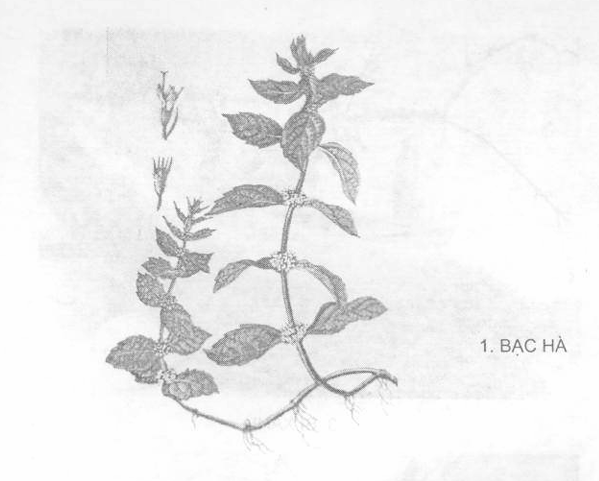

(Ảnh minh họa: data2-pic1.docx.png)
Bài 1.
Chữa cảm mạo, nhức đâu:
Lá bạc hà 6g
Hương nhu 6g
Lá kinh giới 6g
Cam thảo nam 6g
Lá tía tô Gg
Cô mân trầu 6g
Hành hoa 6g
Gừng tươi 8lát
Tất cả thái nhỏ hãm với 300 mì nước sôi trong lỗ
phút, uống lúc đang nóng.
Bài 2.
Chữa cảm sốt, khát nước, ăn uống không tiêu, bụng
đây trướng.
Lá bạc hà 8g
Thái nhỏ hãm với 300ml nước sôi, cách 2 giờ uống 1
lần. Trẻ em dưới 1 tuổi không dùng.

--- [Nguồn trích dẫn tốt nhất] ---

55. Thanh nhiệt, sinh nước bọt, chống khô,
hóa ẩm, tiêu đờm. Chữa bệnh trẻ em khò khè,
khó thở
Đậu phụ chấm bột cành vừng:
Lấy cành vừng băm vụn, sao khô bằng nổi đất, nghiền
nát, không cho gia vị, khi ăn chấm đậu phụ với bột này.
Mỗi ngày ăn hai lần.



In [ ]:
chatbot_final_mixed("Tôi thèm ăn pizza và bị lở tôi muốn dùng cây thuốc có cây thuốc nào chữa không?")